In [2]:
import pandas as pd
import numpy as np

files = {
    'results_1.csv':  -1,
    'results_0.5.csv': -0.5,
    'results_2.csv':  -2,
    'results0.csv':    0,
    'results03.csv':   0.3
}

dfs = []
for fname, r_val in files.items():
    df = pd.read_csv(fname, header=0, skip_blank_lines=True, engine='python')
    print(f"{fname}: columns = {df.columns.tolist()}")
    print(df.head(2))
    df.columns = ['Name', 'r', 'd', 'D', 'Moment', 'Stress', 'Life', 'SF']
    df['R'] = r_val
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data = data.drop(columns=['Name', 'Stress', 'Life'])

bad_geometry = data[data['D'] <= data['d']]
negative_sf  = data[data['SF'] <= 0]

print(f"Total points: {len(data)}")
print(f"Bad geometry (D <= d): {len(bad_geometry)}")
print(f"Negative/zero SF: {len(negative_sf)}")

if len(bad_geometry) > 0:
    print(bad_geometry)
if len(negative_sf) > 0:
    print(negative_sf)

data = data[data['D'] > data['d']]
data = data[data['SF'] > 0]

print(f"\nClean dataset size: {len(data)}")
print(data.describe())

results_1.csv: columns = ['Name', 'r', 'd', 'D', 'Moment X Component [N m]', 'Equivalent Stress Maximum [Pa]', 'Life Minimum', 'Safety Factor']
   Name    r     d     D  Moment X Component [N m]  \
0   NaN  NaN   NaN   NaN                       NaN   
1   1.0  1.5  30.7  42.2                     107.5   

   Equivalent Stress Maximum [Pa]  Life Minimum  Safety Factor  
0                             NaN           NaN            NaN  
1                     12490050.64     1000000.0       6.901493  
results_0.5.csv: columns = ['Name', 'r', 'd', 'D', 'Moment X Component (N m) ', 'Equivalent Stress Maximum (Pa) ', 'Life Minimum', 'Safety Factor']
   Name    r      d      D  Moment X Component (N m)   \
0     1  1.0  20.00  40.00                 625.000000   
1     2  1.5  34.34  60.59                 923.193355   

   Equivalent Stress Maximum (Pa)    Life Minimum  Safety Factor  
0                     2.630932e+08    15567.39808       0.411171  
1                     8.501640e+07  1000000.

Clean dataset: 314 points

Optimized kernel: 8.21**2 * Matern(length_scale=6.31, nu=2.5)

Test RMSE : 0.1871
Test R²   : 0.9905


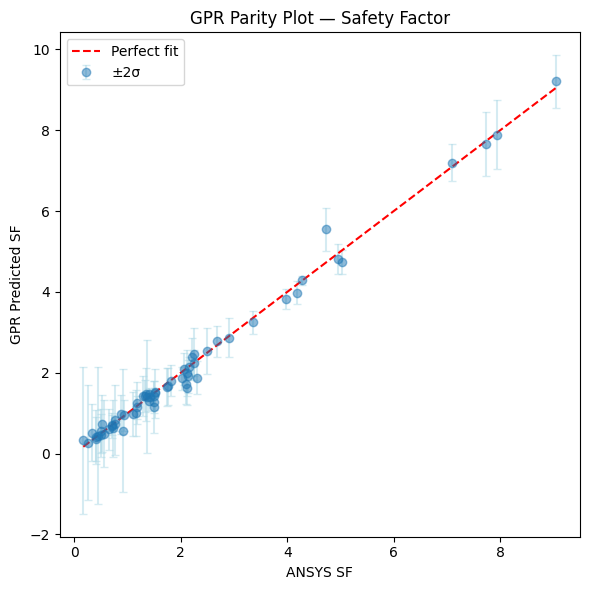

Parity plot saved.


In [3]:
import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

files = {
    'results_1.csv':  -1,
    'results_0.5.csv': -0.5,
    'results_2.csv':  -2,
    'results0.csv':    0,
    'results03.csv':   0.3
}

dfs = []
for fname, r_val in files.items():
    df = pd.read_csv(fname, header=0, skip_blank_lines=True, engine='python')
    df.columns = ['Name', 'r', 'd', 'D', 'Moment', 'Stress', 'Life', 'SF']
    df['R'] = r_val
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data = data.drop(columns=['Name', 'Stress', 'Life'])
data = data[data['D'] > data['d']]
data = data[data['SF'] > 0].reset_index(drop=True)

print(f"Clean dataset: {len(data)} points")

X = data[['r', 'd', 'D', 'Moment', 'R']].values
y = data['SF'].values

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Scale inputs
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

#GPR with Matern kernel
kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,       # noise term for numerical stability
    normalize_y=True,
    n_restarts_optimizer=5
)

gpr.fit(X_train_s, y_train)
print(f"\nOptimized kernel: {gpr.kernel_}")

#Predictions with uncertainty
y_pred, y_std = gpr.predict(X_test_s, return_std=True)

#Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"\nTest RMSE : {rmse:.4f}")
print(f"Test R²   : {r2:.4f}")

#Parity plot
plt.figure(figsize=(6, 6))
plt.errorbar(y_test, y_pred, yerr=2*y_std, fmt='o', alpha=0.5,
             ecolor='lightblue', capsize=3, label='±2σ')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect fit')
plt.xlabel('ANSYS SF')
plt.ylabel('GPR Predicted SF')
plt.title('GPR Parity Plot — Safety Factor')
plt.legend()
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=150)
plt.show()
print("Parity plot saved.")

In [4]:
 #5-fold cross validation
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import cross_val_score, KFold

X_s = scaler.fit_transform(X)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    GaussianProcessRegressor(
        kernel=kernel, alpha=1e-6, normalize_y=True,
        n_restarts_optimizer=3,
        optimizer='fmin_l_bfgs_b'
    ),
    X_s, y, cv=kf, scoring='r2'
)
print(f"\n5-Fold CV R² scores: {cv_scores.round(4)}")
print(f"Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

#Check which R values fall in worst fold
from sklearn.model_selection import KFold
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_s)):
    r_vals = data.iloc[val_idx]['R'].value_counts()
    print(f"Fold {fold+1} R distribution:\n{r_vals}\n")


5-Fold CV R² scores: [0.9906 0.9292 0.9726 0.9802 0.9829]
Mean CV R²: 0.9711 ± 0.0217
Fold 1 R distribution:
R
-1.0    23
-0.5    13
-2.0    11
 0.0     8
 0.3     8
Name: count, dtype: int64

Fold 2 R distribution:
R
-1.0    29
 0.0    11
 0.3    10
-2.0     8
-0.5     5
Name: count, dtype: int64

Fold 3 R distribution:
R
-2.0    16
-1.0    15
-0.5    14
 0.0     9
 0.3     9
Name: count, dtype: int64

Fold 4 R distribution:
R
-1.0    24
 0.3    12
-0.5    11
 0.0    11
-2.0     5
Name: count, dtype: int64

Fold 5 R distribution:
R
-1.0    23
 0.3    11
 0.0    11
-2.0    10
-0.5     7
Name: count, dtype: int64




Permutation Importance (drop in R²):
  d       : 1.8018 ± 0.5172
  Moment  : 1.0518 ± 0.3213
  R       : 0.4201 ± 0.0905
  D       : 0.3189 ± 0.1172
  r       : 0.1712 ± 0.0434


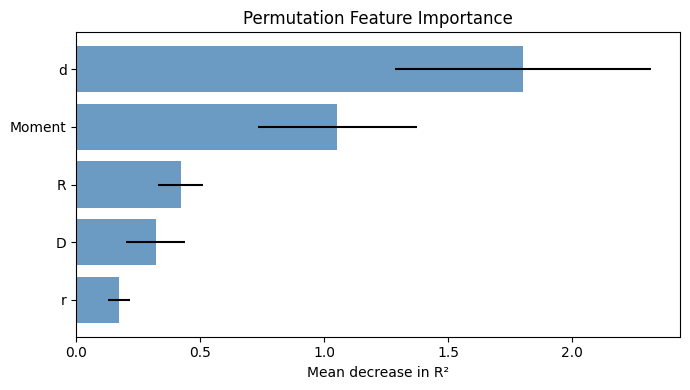

Feature importance plot saved.
Fold 1 R distribution:
R
-1.0    23
-0.5    13
-2.0    11
 0.0     8
 0.3     8
Name: count, dtype: int64

Fold 2 R distribution:
R
-1.0    29
 0.0    11
 0.3    10
-2.0     8
-0.5     5
Name: count, dtype: int64

Fold 3 R distribution:
R
-2.0    16
-1.0    15
-0.5    14
 0.0     9
 0.3     9
Name: count, dtype: int64

Fold 4 R distribution:
R
-1.0    24
 0.3    12
-0.5    11
 0.0    11
-2.0     5
Name: count, dtype: int64

Fold 5 R distribution:
R
-1.0    23
 0.3    11
 0.0    11
-2.0    10
-0.5     7
Name: count, dtype: int64



In [5]:
#Sensitivity Analysis via Permutation Importance
from sklearn.inspection import permutation_importance

#Use the already-fitted gpr on test set
perm = permutation_importance(
    gpr, X_test_s, y_test,
    n_repeats=30, random_state=42, scoring='r2'
)

feat_names = ['r', 'd', 'D', 'Moment', 'R']
sorted_idx = perm.importances_mean.argsort()[::-1]

print("\nPermutation Importance (drop in R²):")
for i in sorted_idx:
    print(f"  {feat_names[i]:8s}: {perm.importances_mean[i]:.4f} ± {perm.importances_std[i]:.4f}")

plt.figure(figsize=(7, 4))
plt.barh(
    [feat_names[i] for i in sorted_idx[::-1]],
    perm.importances_mean[sorted_idx[::-1]],
    xerr=perm.importances_std[sorted_idx[::-1]],
    color='steelblue', alpha=0.8
)
plt.xlabel('Mean decrease in R²')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Feature importance plot saved.")

#Check which R values fall in worst fold
from sklearn.model_selection import KFold
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_s)):
    r_vals = data.iloc[val_idx]['R'].value_counts()
    print(f"Fold {fold+1} R distribution:\n{r_vals}\n")

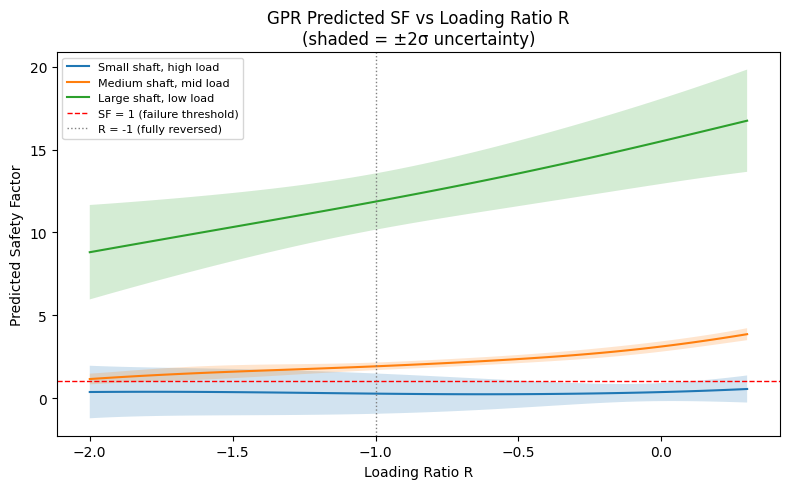

SF vs R plot saved.


In [6]:
#SF vs R plot
R_sweep = np.linspace(-2, 0.3, 100)

cases = [
    {'label': 'Small shaft, high load',  'r': 1.0, 'd': 22.0, 'D': 35.0, 'Moment': 850},
    {'label': 'Medium shaft, mid load',  'r': 2.5, 'd': 32.0, 'D': 50.0, 'Moment': 550},
    {'label': 'Large shaft, low load',   'r': 4.0, 'd': 42.0, 'D': 60.0, 'Moment': 250},
]

plt.figure(figsize=(8, 5))

for case in cases:
    X_sweep = np.array([
        [case['r'], case['d'], case['D'], case['Moment'], r] for r in R_sweep
    ])
    X_sweep_s = scaler.transform(X_sweep)
    sf_pred, sf_std = gpr.predict(X_sweep_s, return_std=True)

    plt.plot(R_sweep, sf_pred, label=case['label'])
    plt.fill_between(R_sweep,
                     sf_pred - 2*sf_std,
                     sf_pred + 2*sf_std,
                     alpha=0.2)

plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='SF = 1 (failure threshold)')
plt.axvline(x=-1.0, color='gray', linestyle=':', linewidth=1, label='R = -1 (fully reversed)')
plt.xlabel('Loading Ratio R')
plt.ylabel('Predicted Safety Factor')
plt.title('GPR Predicted SF vs Loading Ratio R\n(shaded = ±2σ uncertainty)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('sf_vs_R.png', dpi=150)
plt.show()
print("SF vs R plot saved.")